In [4]:
# Upload file
from google.colab import files
uploaded = files.upload()

# Load dataset
import pandas as pd
data = pd.read_csv("loan_approval_data.csv")

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["EmploymentStatus", "MaritalStatus", "LoanApproved"]:
    data[col] = le.fit_transform(data[col])

# Split data
from sklearn.model_selection import train_test_split

X = data.drop("LoanApproved", axis=1)
y = data["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Saving loan_approval_data.csv to loan_approval_data.csv
Accuracy: 1.0
Confusion Matrix:
 [[43  0]
 [ 0  7]]


Saving loan_approval_data.csv to loan_approval_data (1).csv
Dataset Shape: (250, 7)
   Income  CreditScore  LoanAmount EmploymentStatus  ExistingDebt  \
0   35795          845       35977         Employed         18755   
1   20860          646       34168         Employed          2891   
2   96820          647       30471         Employed          3756   
3   74886          698       27687    Self-Employed         20609   
4   26265          807        5851         Employed         15770   

  MaritalStatus LoanApproved  
0       Married           No  
1        Single           No  
2        Single           No  
3        Single           No  
4       Married           No  
Accuracy: 0.9

Confusion Matrix:
 [[34  2]
 [ 3 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        36
           1       0.85      0.79      0.81        14

    accuracy                           0.90        50
   macro avg       

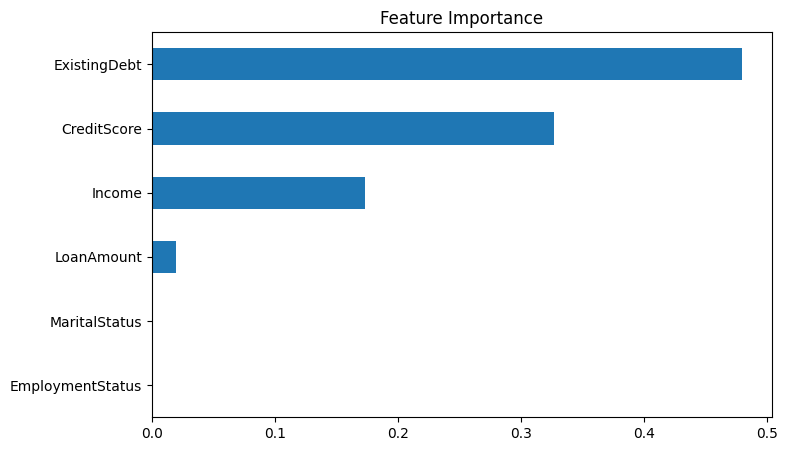

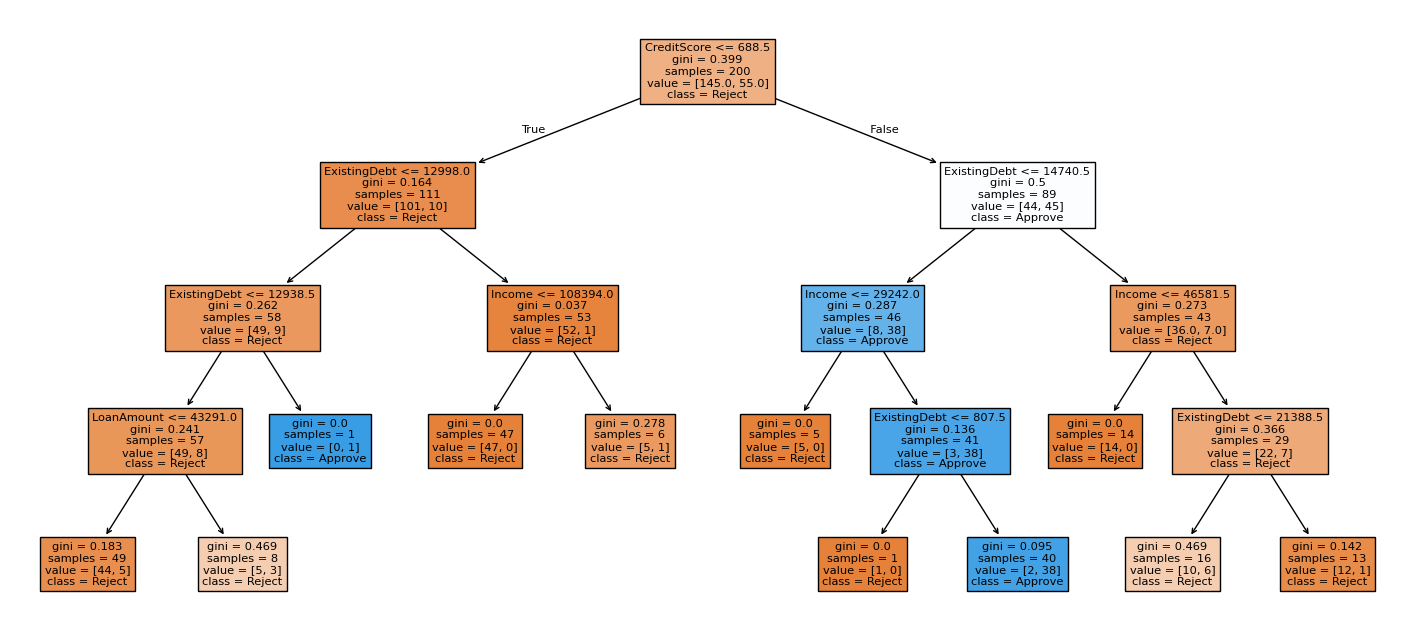

In [5]:
# ==============================
#Upload Dataset (Colab)
# ==============================
from google.colab import files
uploaded = files.upload()

# ==============================
# Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==============================
#  Load Dataset
# ==============================
data = pd.read_csv("loan_approval_data.csv")

print("Dataset Shape:", data.shape)
print(data.head())

# ==============================
#  Encode Categorical Variables
# ==============================
categorical_cols = ["EmploymentStatus", "MaritalStatus", "LoanApproved"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

# ==============================
#  Add Noise (Optional - Realistic Scenario)
# ==============================
np.random.seed(42)
flip_ratio = 0.1
flip_indices = np.random.choice(
    data.index, size=int(flip_ratio * len(data)), replace=False
)
data.loc[flip_indices, "LoanApproved"] = 1 - data.loc[flip_indices, "LoanApproved"]

# ==============================
#  Split Features & Target
# ==============================
X = data.drop("LoanApproved", axis=1)
y = data["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==============================
#Train Decision Tree
# ==============================
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
#  Predict & Evaluate
# ==============================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==============================
# Feature Importance
# ==============================
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

# ==============================
# Visualize Decision Tree
# ==============================
plt.figure(figsize=(18,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Reject", "Approve"],
    filled=True
)
plt.show()